In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

In [2]:
df=pd.read_csv(r"D:\allFiles\mango_soil_dataset_5000.csv")

In [3]:

print(df.head())
print(df.info())
print(df.isnull().sum())

   Soil_Moisture    Nitrogen  Phosphorus   Potassium  Light_Density  \
0      34.266812  105.436312   63.847270  206.179338    4251.107935   
1      70.230587  135.900822   72.224787  190.147342    6035.500335   
2      46.712066  158.840118   28.465888  100.839977    9317.125788   
3      60.042490  162.556565   85.773759  107.952302    2611.685406   
4      63.264420  242.882398   15.274198  185.970125    1605.149133   

   Irrigation   Soil_pH        EC  Temperature   Humidity  Feasible  
0    2.891046  4.695957  2.382452    19.050872  72.944720         0  
1    8.862301  6.753384  1.936244    26.434568  43.190540         0  
2    3.749037  8.221300  1.067573    27.492599  53.795114         0  
3    6.747649  8.436884  1.782908    40.373275  85.871177         0  
4    1.128320  5.579169  0.524121    36.855865  72.917560         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
--

In [4]:
X = df.drop('Feasible', axis=1)
y = df['Feasible']

In [5]:
le = LabelEncoder()
y = le.fit_transform(y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

c:\Python312\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


,objective,'binary:logistic'
,use_label_encoder,False
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [8]:
y_pred = model.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.995


In [10]:
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)

Precision: 0.9950251256281407


In [11]:
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)

Recall: 0.995


In [12]:
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.9941729638958858


[[990   0]
 [  5   5]]


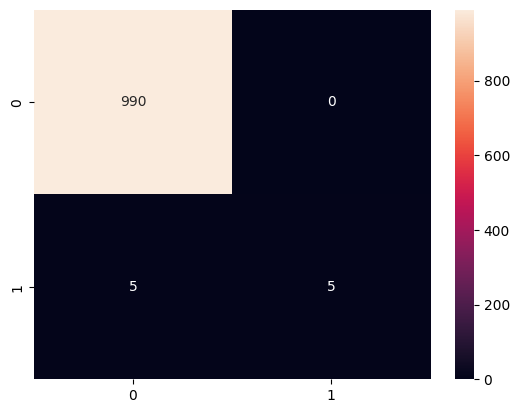

In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       990
           1       1.00      0.50      0.67        10

    accuracy                           0.99      1000
   macro avg       1.00      0.75      0.83      1000
weighted avg       1.00      0.99      0.99      1000



In [15]:
print(pd.Series(y).value_counts())

0    4951
1      49
Name: count, dtype: int64


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [17]:
model2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model2.fit(X_resampled, y_resampled)

c:\Python312\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


,objective,'binary:logistic'
,use_label_encoder,False
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [18]:
y_pred2 = model2.predict(X_test)

In [19]:
print("After SMOTE:")

print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2, average='weighted'))
print("Recall:", recall_score(y_test, y_pred2, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred2, average='weighted'))

After SMOTE:
Accuracy: 0.996
Precision: 0.9957560483870967
Recall: 0.996
F1 Score: 0.9957797959412491


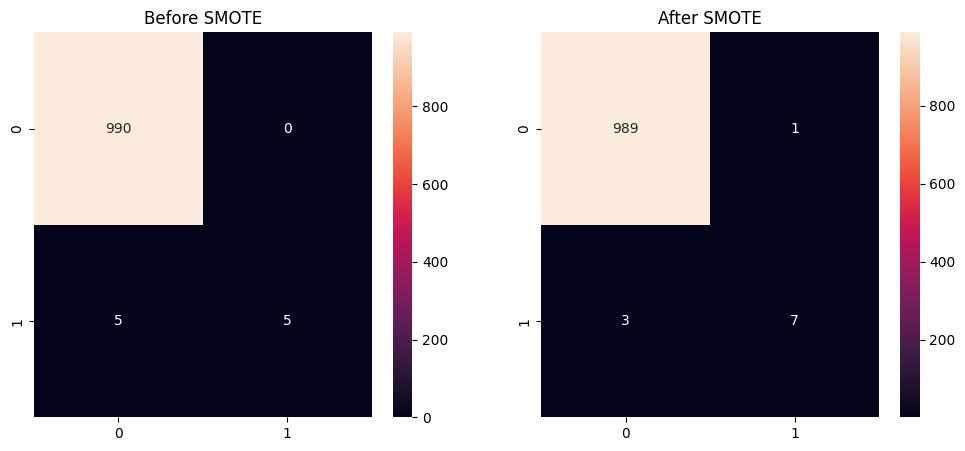

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
cm1 = confusion_matrix(y_test, y_pred)
sns.heatmap(cm1, annot=True, fmt='d')
plt.title("Before SMOTE")

plt.subplot(1,2,2)
cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d')
plt.title("After SMOTE")

plt.show()

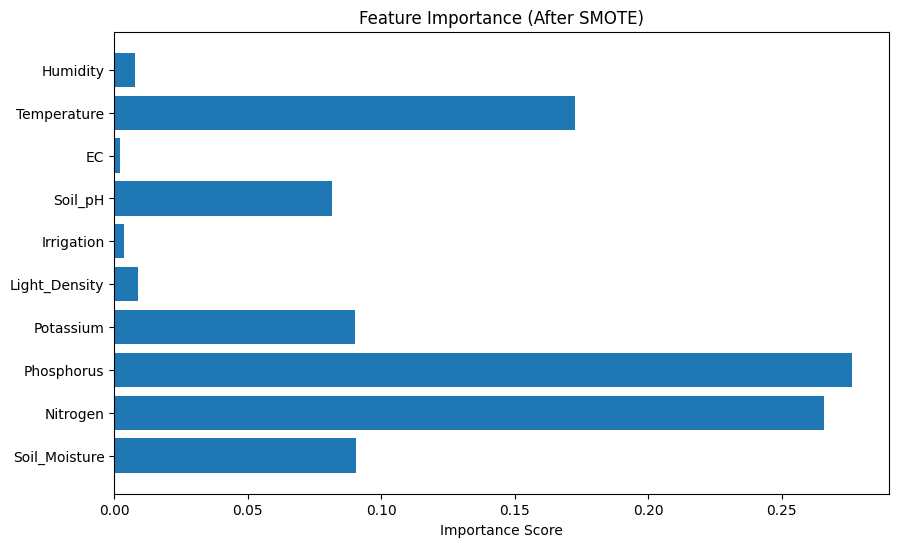

In [21]:


importance = model2.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X_train.columns, importance)
plt.title("Feature Importance (After SMOTE)")
plt.xlabel("Importance Score")
plt.show()

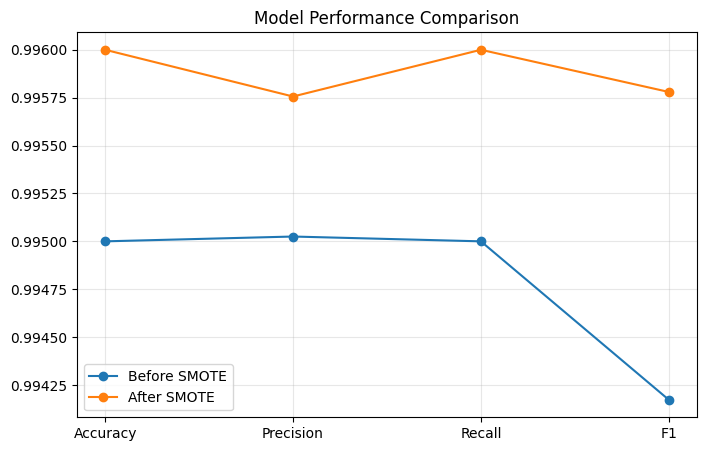

In [22]:
labels = ["Accuracy", "Precision", "Recall", "F1"]

before = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, average='weighted'),
    recall_score(y_test, y_pred, average='weighted'),
    f1_score(y_test, y_pred, average='weighted')
]

after = [
    accuracy_score(y_test, y_pred2),
    precision_score(y_test, y_pred2, average='weighted'),
    recall_score(y_test, y_pred2, average='weighted'),
    f1_score(y_test, y_pred2, average='weighted')
]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.plot(x, before, marker='o', label="Before SMOTE")
plt.plot(x, after, marker='o', label="After SMOTE")

plt.xticks(x, labels)
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

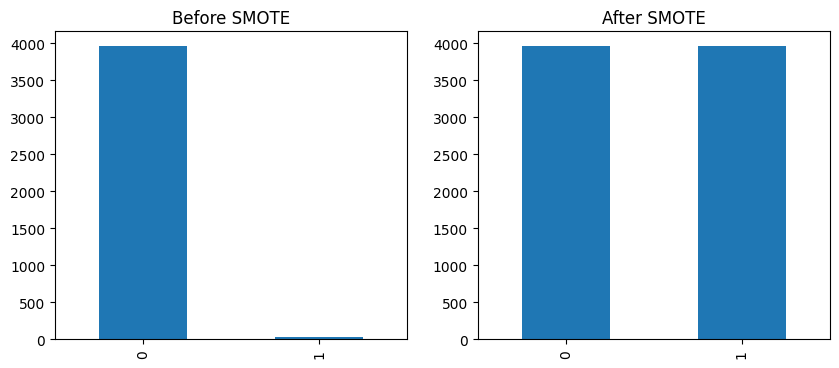

In [23]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
pd.Series(y_train).value_counts().plot(kind='bar')
plt.title("Before SMOTE")

plt.subplot(1,2,2)
pd.Series(y_resampled).value_counts().plot(kind='bar')
plt.title("After SMOTE")

plt.show()